# A propeller, rest to full and back

The Hobbywing Platinum 5230SL 190KV turning an APC20x10E from 0 rpm to
6717 and back down, and what the coaxial 63100 has to supply to do it.

Every electrical constant is an estimate — `PLATINUM_5230SL` carries
`measured=False` and no motor has turned on this bench. The propeller is
not an estimate: `APC20x10E.k` is a least squares over Hobbywing's own
22-point thrust stand, and the last figure puts the model back against
those points.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

root = Path.cwd()
while not (root / 'host' / 'coaxial').is_dir():
    root = root.parent
sys.path.insert(0, str(root / 'host'))

from coaxial.motor import (APC20x10E, APC20X10E_CURVE, KT_NM_PER_AMP,
                           PLATINUM_5230SL, RATINGS)

SPEED, POWER, SHEET = '#1f4e79', '#c0392b', '#95a5a6'
plt.rcParams.update({
    'figure.figsize': (9, 3.8), 'figure.dpi': 120,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.15, 'grid.linewidth': 0.6,
    'font.size': 9, 'axes.labelsize': 9, 'legend.frameon': False,
})

motor, prop = PLATINUM_5230SL, APC20x10E
print(motor)
print(prop, '--', prop.source)
print('rated %(i_max)s A for %(t_i_max)s s on %(cells)s' % RATINGS)

<Hobbywing Platinum 5230SL 190KV ESTIMATED: R 0.0300 ohm, Ld 22.0 uH, Lq 29.0 uH, lambda 0.00207 Wb, 14 pole pairs, KV 190>
<APC20x10E: 5.143e-06 N.m/(rad/s)^2> -- least squares over the 190KV sheet, 37 V, 25 C, sea level
rated 112.5 A for 42.0 s on 10-12S LiPo


## The profile

A raised cosine — zero speed **and** zero acceleration at both ends, so
the torque never steps into the stage. Four seconds up, four back.

The step is 1 ms because the mechanics are slow: `J/b` is 0.7 s. The board
runs its own loop at 20 µs and would resolve every one of these points
8 000 times over.

In [2]:
TOP_RPM = APC20X10E_CURVE[-1][0]              # 6717, the top of the sheet
RISE, DT = 4.0, 1e-3

t = np.arange(0.0, 2 * RISE, DT)
top = TOP_RPM / 60.0 * 2 * np.pi                       # rad/s mechanical
w = top * 0.5 * (1.0 - np.cos(np.pi * t / RISE))
alpha = np.gradient(w, DT)

print('top %.0f rpm = %.0f rad/s mechanical, %.0f Hz electrical'
      % (TOP_RPM, top, top * motor.poles / (2 * np.pi)))
print('peak acceleration %.0f rad/s^2' % np.abs(alpha).max())

top 6717 rpm = 703 rad/s mechanical, 1567 Hz electrical
peak acceleration 276 rad/s^2


## What it costs

Three torques and one loss. The propeller goes as $\omega^2$, the iron and
bearings as $\omega$ — that term is the datasheet's own no-load figure,
3.0 A at 44.4 V — and the rotor takes $J\alpha$ on the way up and gives it
back on the way down.

In [3]:
t_prop, t_drag, t_accel = prop.k * w ** 2, motor.b * w, motor.j * alpha
torque = t_prop + t_drag + t_accel
iq = torque / KT_NM_PER_AMP

run = pd.DataFrame({
    'rpm': w * 60.0 / (2 * np.pi),
    'iq_A': iq,
    'torque_Nm': torque,
    'prop_W': t_prop * w,
    'drag_W': t_drag * w,
    'accel_W': t_accel * w,
    'copper_W': 1.5 * iq ** 2 * motor.r,
}, index=pd.Index(t.round(4), name='s'))
run['shaft_W'] = run.prop_W + run.drag_W + run.accel_W
run['input_W'] = run.shaft_W + run.copper_W

run.iloc[::800].round(1)

,rpm,iq_A,torque_Nm,prop_W,drag_W,accel_W,copper_W,shaft_W,input_W
s,,,,,,,,,
0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0.8,641.4,1.2,0.1,1.6,0.8,1.3,0.1,3.6,3.7
1.6,2320.7,8.7,0.4,73.8,10.1,7.7,3.4,91.6,95.0
2.4,4396.3,27.6,1.2,501.9,36.2,14.5,34.3,552.6,586.9
3.2,6075.6,50.8,2.2,1324.5,69.2,12.4,116.2,1406.2,1522.3
4.0,6717.0,61.3,2.7,1789.9,84.6,0.0,168.9,1874.5,2043.4
4.8,6075.6,49.9,2.2,1324.5,69.2,-12.4,112.1,1381.4,1493.5
5.6,4396.3,26.1,1.1,501.9,36.2,-14.5,30.8,523.6,554.3
6.4,2320.7,7.2,0.3,73.8,10.1,-7.7,2.3,76.3,78.6


## The arc

Speed and power rise and fall together. They are not the same curve: the
propeller absorbs $k\omega^3$, so the power peaks harder and later than
the speed does.

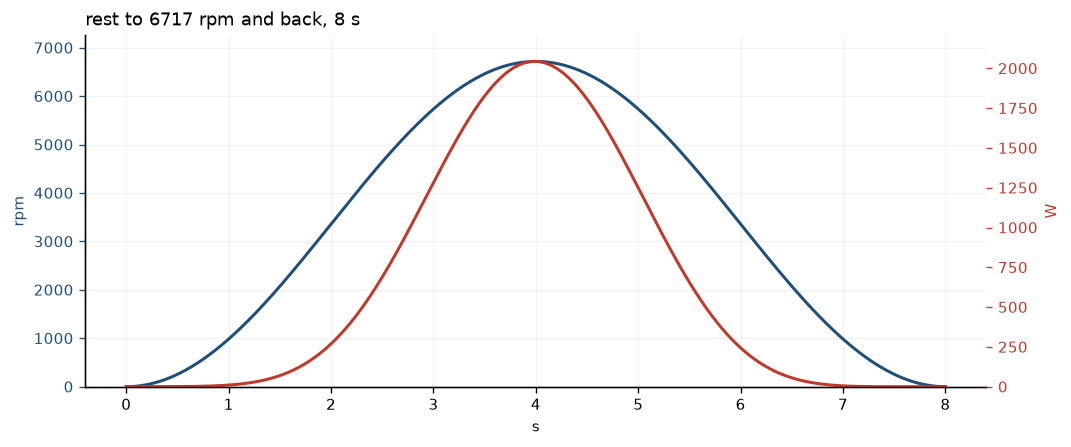

In [4]:
fig, ax = plt.subplots()
ax.plot(run.index, run.rpm, color=SPEED, lw=1.8)
ax.set_xlabel('s')
ax.set_ylabel('rpm', color=SPEED)
ax.tick_params(axis='y', colors=SPEED)
ax.set_ylim(0, TOP_RPM * 1.08)

watts = ax.twinx()
watts.plot(run.index, run.input_W, color=POWER, lw=1.8)
watts.set_ylabel('W', color=POWER)
watts.tick_params(axis='y', colors=POWER)
watts.spines['top'].set_visible(False)
watts.set_ylim(0, run.input_W.max() * 1.08)
watts.grid(False)

ax.set_title('rest to %d rpm and back, %.0f s' % (TOP_RPM, 2 * RISE),
             loc='left')
fig.tight_layout()

## Where the power goes

The rotor's energy is borrowed, not spent: `accel_W` is the mirror image
of itself either side of the top, and the area above the axis equals the
area below it.

rotor took 29.7 J up, gave 29.7 J back


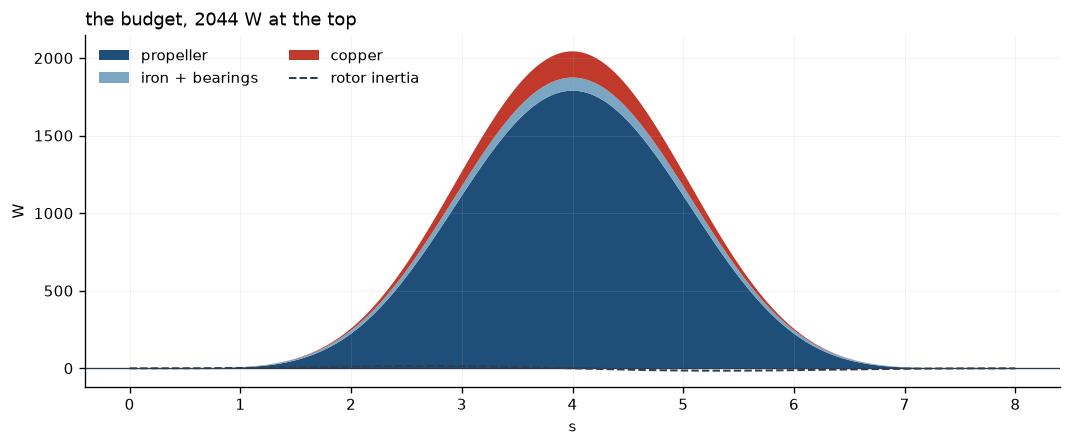

In [5]:
fig, ax = plt.subplots()
ax.stackplot(run.index, run.prop_W.clip(lower=0), run.drag_W,
             run.copper_W,
             labels=['propeller', 'iron + bearings', 'copper'],
             colors=['#1f4e79', '#7aa6c2', '#c0392b'], lw=0)
ax.plot(run.index, run.accel_W, color='#2c3e50', lw=1.2, ls='--',
        label='rotor inertia')
ax.axhline(0, color='#2c3e50', lw=0.8)
ax.set_xlabel('s')
ax.set_ylabel('W')
ax.legend(loc='upper left', ncol=2)
ax.set_title('the budget, %.0f W at the top' % run.input_W.max(), loc='left')
fig.tight_layout()

borrowed = run.accel_W.clip(lower=0).sum() * DT
returned = -run.accel_W.clip(upper=0).sum() * DT
print('rotor took %.1f J up, gave %.1f J back' % (borrowed, returned))

## Against the thrust stand

The model was fitted for its `k` alone. Everything else in this curve —
the copper, the iron term, the torque constant — came from elsewhere, so
the residual below is a check and not a tautology.

,rpm,torque_Nm,input_W,model_W,err_pct
16,5518,1.7,1117.7,1144.7,2.4
17,5703,1.8,1244.1,1262.0,1.4
18,5883,2.0,1380.8,1383.7,0.2
19,6058,2.1,1527.6,1509.3,-1.2
20,6226,2.3,1683.8,1636.8,-2.8
21,6717,2.8,2214.0,2043.4,-7.7


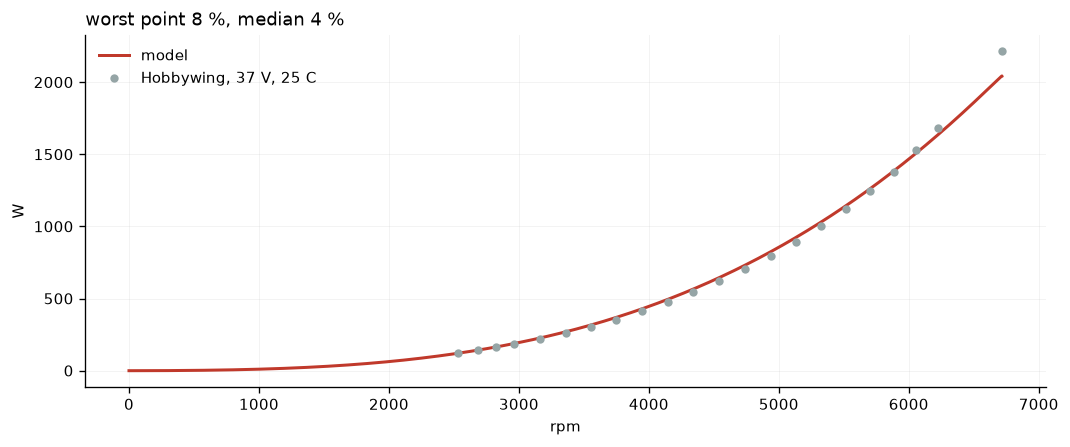

In [6]:
sheet = pd.DataFrame(APC20X10E_CURVE, columns=['rpm', 'torque_Nm', 'input_W'])
up = run.loc[:RISE]
fit = np.interp(sheet.rpm, up.rpm, up.input_W)
sheet['model_W'] = fit
sheet['err_pct'] = (fit - sheet.input_W) / sheet.input_W * 100.0

fig, ax = plt.subplots()
ax.plot(up.rpm, up.input_W, color=POWER, lw=1.8, label='model')
ax.plot(sheet.rpm, sheet.input_W, 'o', ms=5, color=SHEET, mew=0,
        label='Hobbywing, 37 V, 25 C')
ax.set_xlabel('rpm')
ax.set_ylabel('W')
ax.legend(loc='upper left')
ax.set_title('worst point %.0f %%, median %.0f %%'
             % (sheet.err_pct.abs().max(), sheet.err_pct.abs().median()),
             loc='left')
fig.tight_layout()

sheet.round(1).tail(6)

The model runs under the stand because it accounts for no ESC loss and no
windage on the bell. The sheet's watts are what went **into** the
controller; these are what leaves the inverter.

## What the board would have to be

The profile is only interesting if the hardware can serve it. Current is
the easy half.

In [7]:
peak_A = run.iq_A.max()
w_e = top * motor.poles                              # rad/s electrical
bemf = w_e * motor.lam                               # phase amplitude
cross = w_e * motor.lq * peak_A                      # the omega Lq iq term
need = np.hypot(bemf + motor.r * peak_A, cross)

print('peak q current %6.1f A     board 100, motor %.1f'
      % (peak_A, RATINGS['i_max']))
print('back-EMF       %6.1f V     phase, %.1f line to line'
      % (bemf, bemf * np.sqrt(3)))
print('cross coupling %6.1f V     omega Lq iq, on the d axis' % cross)
print('demand         %6.1f V     the vector, at the top' % need)
print()
for cells, volts in ((10, 3.7), (12, 3.7), (12, 4.2)):
    vdc = cells * volts
    ceiling = vdc / np.sqrt(3)                       # linear SVM, phase
    print('%2dS at %.1f V = %4.1f V link -> %5.1f V phase, %+6.1f %%'
          % (cells, volts, vdc, ceiling, (ceiling / need - 1) * 100))
print()
print('12S full charge is %.1f V of the 63 V rating, %.0f %% of the '
      '78.15 V divider' % (12 * 4.2, 12 * 4.2 / 78.15 * 100))

peak q current   61.3 A     board 100, motor 112.5
back-EMF         20.4 V     phase, 35.4 line to line
cross coupling   17.5 V     omega Lq iq, on the d axis
demand           28.3 V     the vector, at the top

10S at 3.7 V = 37.0 V link ->  21.4 V phase,  -24.5 %
12S at 3.7 V = 44.4 V link ->  25.6 V phase,   -9.4 %
12S at 4.2 V = 50.4 V link ->  29.1 V phase,   +2.8 %

12S full charge is 50.4 V of the 63 V rating, 64 % of the 78.15 V divider


**The voltage is the half that bites.** Hobbywing reached 6717 rpm on 10S,
and this model wants a third more phase voltage than linear SVM can make
from 37 V. Both cannot be true, and the disagreement is worth more than
either number alone — it says one of three things, all testable:

| | |
|---|---|
| `Lq` is over-estimated | the cross term is the largest single item above, and `Lq` is the constant flagged least trustworthy in `motor.py` |
| the stand's ESC left linear modulation | six-step reaches a higher fundamental than SVM does, and a hobby controller at full throttle is not being polite |
| `lambda` is high | it comes from the label, and a label is a round number |

For **this** board, driving sine, the arithmetic says a fully charged 12S —
and that a top-speed run wants field weakening rather than more cells.

`coaxial.sysid` settles it: `Lq` off a real machine turns the table above
into one line. `tools/observer_run.py` covers the other end — it runs the
firmware's own observer against this motor and finds the start, not the
speed, is the hard part: a 45 A step holds, 50 A stalls in the handover.
This profile never steps its current, which is the shape that works.

Nothing here has been near a motor.